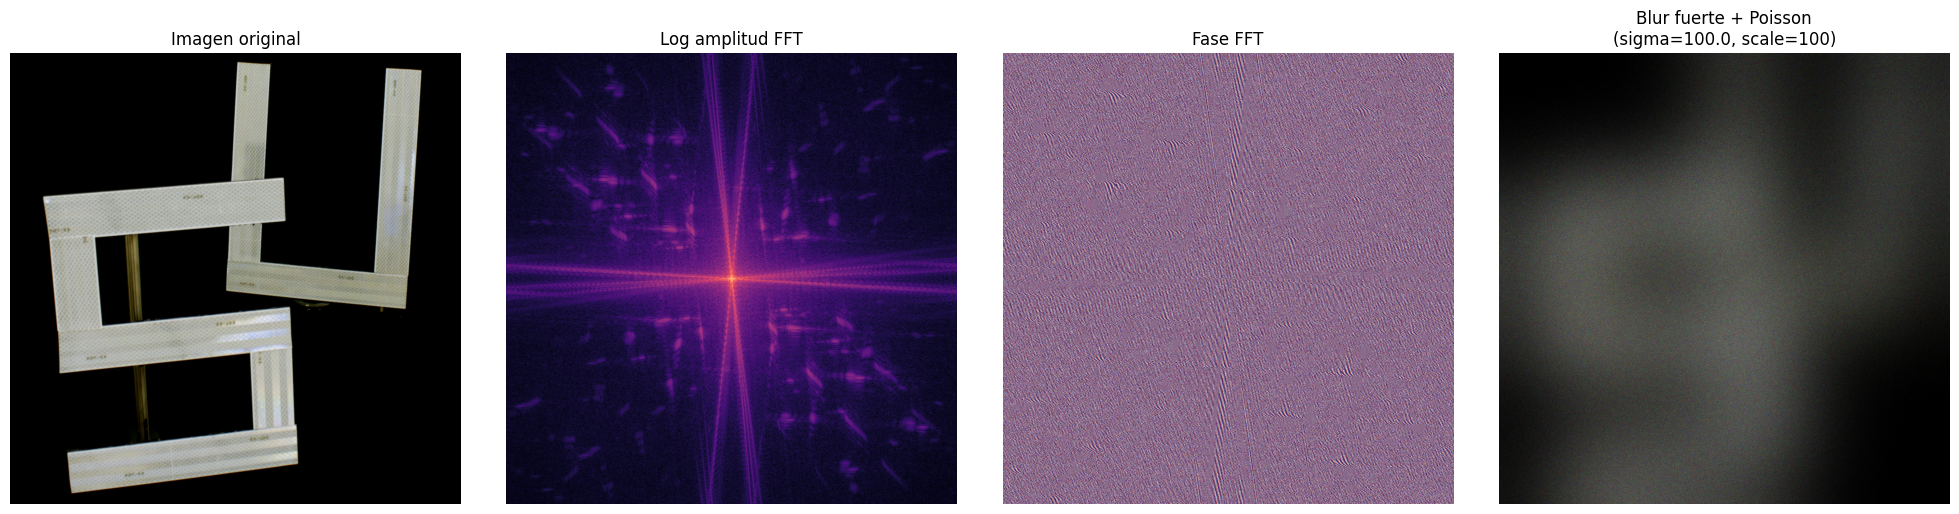

img_rgb.shape = (1000, 1000, 3)
img_gray.shape = (1000, 1000)
amplitude.shape = (1000, 1000)
phase.shape = (1000, 1000)
blurred.shape = (1000, 1000, 3)
distorted.shape = (1000, 1000, 3)
Nota: esta fase es la fase de Fourier de la imagen, no una fase optica medida del objeto.


In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter

img_path = Path('/home/cristiancrr/demo_nlos/data/scenes/blends/su.png')

img_rgb = np.asarray(Image.open(img_path).convert('RGB'), dtype=np.float32) / 255.0
img_gray = np.asarray(Image.open(img_path).convert('L'), dtype=np.float32) / 255.0

# Amplitud y fase en el dominio de Fourier de la imagen en gris.
fft_img = np.fft.fftshift(np.fft.fft2(img_gray))
amplitude = np.abs(fft_img)
phase = np.angle(fft_img)
log_amplitude = np.log1p(amplitude)

# Blur gaussiano fuerte seguido de ruido Poisson.
blur_sigma = 100.0
blurred = gaussian_filter(img_rgb, sigma=(blur_sigma, blur_sigma, 0))

# La escala controla cuanta energia llega al sensor antes del muestreo Poisson.
poisson_scale = 100
rng = np.random.default_rng(42)
distorted = rng.poisson(np.clip(blurred, 0, 1) * poisson_scale).astype(np.float32) / poisson_scale

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Imagen original')
axes[1].imshow(log_amplitude, cmap='magma')
axes[1].set_title('Log amplitud FFT')
axes[2].imshow(phase, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[2].set_title('Fase FFT')
axes[3].imshow(np.clip(distorted, 0, 1))
axes[3].set_title(f'Blur fuerte + Poisson\n(sigma={blur_sigma}, scale={poisson_scale})')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'img_rgb.shape = {img_rgb.shape}')
print(f'img_gray.shape = {img_gray.shape}')
print(f'amplitude.shape = {amplitude.shape}')
print(f'phase.shape = {phase.shape}')
print(f'blurred.shape = {blurred.shape}')
print(f'distorted.shape = {distorted.shape}')
print('Nota: esta fase es la fase de Fourier de la imagen, no una fase optica medida del objeto.')
